<a href="https://colab.research.google.com/github/KedaarK/ML-Experiments-D17A/blob/main/Batch_A/Exp1_Crafting_the_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Why Crafting the Dataset is important?

**1. Ensures Data Quality (Garbage In, Garbage Out):**

* **Removes Noise:** Data Cleaning (handling missing values, removing duplicates, correcting errors) ensures the model trains on valid, accurate data, preventing poor performance or biased results.

* **Validates Integrity:** Confirms data types are correct and values adhere to domain constraints (e.g., price ≥0).

**2. Unlocks Predictive Power (Feature Engineering):**

* **Extracts Signal:** Creates new, informative features (like price_per_sqft or house_age) that are better predictors than the raw inputs, simplifying the problem for the algorithm.

* **Handles Complex Data:** Decomposes complex features (like dates) into simple, usable components (month, year, day), allowing the model to detect temporal patterns and seasonality.

**3. Optimizes Model Training:**

* **Equal Contribution:** Feature Scaling (Normalization/Standardization) ensures all features contribute equally to the distance calculations and gradient updates, leading to faster and more stable model convergence.

* **Addresses Model Requirements:** Encoding categorical data (One-Hot Encoding, etc.) converts text into numerical format, which is mandatory for virtually all machine learning algorithms.

**4. Improves Model Performance Ceiling:**

* **Model Agnostic:** The performance ceiling of any model (linear, tree-based, neural network) is determined by the quality and relevance of its input features. A well-crafted dataset allows even a simple algorithm to outperform a complex algorithm trained on raw, messy data.

* **Reduces Bias:** By handling outliers and cleaning skewed distributions, the crafted dataset minimizes bias, leading to a more generalized and reliable final model.

# A. Data Preparation in Machine Learning

*   Data preparation is the process of dealing with raw data i.e. cleaning, organizing and transforming it to align with the machine learning algorithms. It ensures that the data is accurate, consistent, and relevant.
*  It involves collecting, cleaning, integrating, transforming, and validating data so it can be effectively used to generate actionable insights and make informed decisions.


# STEP 1: MOUNTING GOOGLE DRIVE AND INITIAL SETUP




In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive to avoid re-uploading dataset
drive.mount('/content/drive')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("✅ Google Drive mounted successfully!")
print("✅ All required libraries imported!")

STEP 1: MOUNTING GOOGLE DRIVE AND INITIAL SETUP
Mounted at /content/drive
✅ Google Drive mounted successfully!
✅ All required libraries imported!


# STEP 2: LOADING COMPLETE CSV DATASET FROM GOOGLE DRIVE

1. **Data Loading and Organization** - DataFrame organizes the raw, unstructured file data into rows (records) and columns (features), which is the standard format required by ML algorithms.
2. **Data Cleaning** - It involves identifying and handling issues like missing values, incorrect data types, and structural problems.

In [ ]:
try:
    # Method 1: If your file is in the root of Google Drive
    df = pd.read_csv('/content/drive/MyDrive/ML/kc_house_data_NaN.csv')
    print("✅ Dataset loaded from Google Drive root directory")

except FileNotFoundError:
    # Method 2: If your file is in a specific folder
    try:
        df = pd.read_csv('/content/drive/MyDrive/ML/kc_house_data_NaN.csv')  # Update folder path
        print("✅ Dataset loaded from ML_Datasets folder")
    except FileNotFoundError:
        # Method 3: Manual file upload if not in Drive
        print("⚠️ CSV file not found in Google Drive!")
        print("📁 Please either:")
        print("   1. Upload your CSV file to Google Drive and update the file path above")
        print("   2. Use the file upload option below")

        from google.colab import files
        print("\n📤 Uploading file manually...")
        uploaded = files.upload()

        # Get the uploaded filename
        filename = list(uploaded.keys())[0]
        df = pd.read_csv(filename)
        print(f"✅ Dataset loaded from uploaded file: {filename}")

# Verify the dataset loaded correctly
print(f"\n📊 Complete Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Total records: {df.shape[0]:,}")
print(f"Total features: {df.shape[1]}")

# Check if columns match expected housing dataset structure
expected_columns = ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
                   'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
                   'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
                   'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

missing_cols = set(expected_columns) - set(df.columns)
if missing_cols:
    print(f"⚠️ Missing expected columns: {missing_cols}")
else:
    print("✅ All expected columns present in dataset")

print(f"\n📋 Actual columns in dataset:")
print(list(df.columns))

print("📊 Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Basic information about the dataset
print("\n🔍 Dataset Info:")
df.info()

print("\n📈 Dataset Statistical Description:")
print(df.describe())

print("\n🎯 First 5 rows of the complete dataset:")
print(df.head())

print("\n🎯 Last 5 rows to verify complete loading:")
print(df.tail())

# Additional dataset insights for large dataset
print(f"\n📊 Dataset Overview:")
print(f"• Memory usage: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")
print(f"• Date range: {df['date'].min() if 'date' in df.columns else 'N/A'} to {df['date'].max() if 'date' in df.columns else 'N/A'}")
if 'price' in df.columns:
    print(f"• Price range: ${df['price'].min():,.0f} - ${df['price'].max():,.0f}")
    print(f"• Average price: ${df['price'].mean():,.0f}")
if 'sqft_living' in df.columns:
    print(f"• Living area range: {df['sqft_living'].min():,} - {df['sqft_living'].max():,} sqft")



STEP 2: LOADING COMPLETE CSV DATASET FROM GOOGLE DRIVE
✅ Dataset loaded from Google Drive root directory

📊 Complete Dataset loaded successfully!
Dataset shape: (21613, 22)
Total records: 21,613
Total features: 22
✅ All expected columns present in dataset

📋 Actual columns in dataset:
['Unnamed: 0', 'id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']
📊 Dataset loaded successfully!
Dataset shape: (21613, 22)
Columns: ['Unnamed: 0', 'id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

🔍 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 22 columns):


# STEP 3: DATA CLEANING OPERATIONS
The code addresses four major areas of data quality:

**1. Handling Missing Values (Data Imputation):**
* **Process**: It first detects missing values using df.isnull().sum(). It then
applies a conditional imputation strategy:
  
  * **Numerical Features** (e.g., price, sqft_living): Missing values are filled with the **median**. The median is used because it is more robust to outliers than the mean, ensuring that extreme house prices or sizes don't skew the imputed value.
  * **Categorical Features** (e.g., Location, if present): Missing values are filled with the mode (most frequent value). It preserves the overall distribution and frequency of the categories.

**2. Handling Duplicates (Data Redundancy):**
* **Process:** It checks for completely identical rows using df.duplicated().sum() and removes them using df.drop_duplicates().

* **Importance:** Duplicate records can severely **bias** a model, especially tree-based or deep learning models, by over-representing specific observations. Removing them ensures the model learns from unique, valid data points.

**3. Data Type Corrections (Format Validation)**
* **Process:** It ensures columns have the correct data type:

  * The date column is converted to the proper datetime object, which is essential for feature engineering (extracting year/month/day).

  * All defined **numerical columns** are explicitly converted to a numeric type. The errors='coerce' parameter handles any non-numeric text in these columns by turning them into **NaN**, which were then handled by the imputation step.

**4. Handling Invalid Values (Domain Constraints):**
* **Process:** It enforces logical, domain-specific constraints:

  * It removes records where key values like price or sqft_living are zero or negative, as these are physically or financially impossible and represent recording errors.

  * It uses the .clip() function to restrict features like bedrooms and bathrooms to a reasonable range (e.g., capping extreme bedroom counts), which is a light form of Outlier Engineering.

* **Importance:** Errors or impossible values act as noise, hindering the model's ability to capture the true underlying patterns. Removing or correcting them improves data quality and model reliability.



In [ ]:
# Check for missing values
print("🔎 Checking for missing values in complete dataset:")
missing_values = df.isnull().sum()
total_missing = missing_values.sum()
missing_percentage = (missing_values / len(df)) * 100

print("Missing values by column:")
for col in missing_values.index:
    if missing_values[col] > 0:
        print(f"  • {col}: {missing_values[col]} ({missing_percentage[col]:.2f}%)")

if total_missing == 0:
    print("✅ No missing values found in the dataset!")
else:
    print(f"⚠️ Total missing values: {total_missing} ({total_missing/(len(df)*len(df.columns))*100:.2f}% of all data)")

    # Handle missing values strategy
    print("\n🔧 Applying missing value treatment:")

    # For numerical columns: fill with median
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"  ✅ {col}: filled with median ({df[col].median():.2f})")

    # For categorical columns: fill with mode
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns
    for col in categorical_cols:
        if col != 'date' and df[col].isnull().sum() > 0:  # Skip date column
            mode_value = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
            df[col].fillna(mode_value, inplace=True)
            print(f"  ✅ {col}: filled with mode ({mode_value})")

    print("✅ Missing values treatment completed!")

# Check for duplicates in the complete dataset
print(f"\n🔍 Checking for duplicates in complete dataset:")
duplicates = df.duplicated().sum()
duplicate_percentage = (duplicates / len(df)) * 100
print(f"Number of duplicate rows: {duplicates} ({duplicate_percentage:.2f}%)")

if duplicates > 0:
    print("🧹 Removing duplicates...")
    original_shape = df.shape
    df = df.drop_duplicates()
    print(f"✅ Duplicates removed! Shape changed from {original_shape} to {df.shape}")
else:
    print("✅ No duplicates found!")

# Data type corrections
print(f"\n🔧 Converting data types for complete dataset:")

# Handle date column conversion more robustly
if 'date' in df.columns:
    try:
        # Try the format from your sample data first
        df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')
        print("✅ Date column converted using format '%Y%m%dT%H%M%S'")
    except ValueError:
        try:
            # Try automatic parsing if the above fails
            df['date'] = pd.to_datetime(df['date'])
            print("✅ Date column converted using automatic parsing")
        except:
            print("⚠️ Could not convert date column - keeping as string")

# Ensure numerical columns are proper numeric types
numerical_columns = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
                    'floors', 'condition', 'grade', 'sqft_above', 'sqft_basement',
                    'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

for col in numerical_columns:
    if col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        except:
            print(f"⚠️ Could not convert {col} to numeric")

print("✅ Data type conversions completed")

# Check for invalid values in the complete dataset
print(f"\n🚨 Checking for invalid values in complete dataset:")

# Check for negative prices or areas
if 'price' in df.columns:
    invalid_price = (df['price'] <= 0).sum()
    print(f"Invalid prices (≤0): {invalid_price}")
    if invalid_price > 0:
        print(f"  Removing {invalid_price} records with invalid prices...")
        df = df[df['price'] > 0]

if 'sqft_living' in df.columns:
    invalid_sqft = (df['sqft_living'] <= 0).sum()
    print(f"Invalid living sqft (≤0): {invalid_sqft}")
    if invalid_sqft > 0:
        print(f"  Removing {invalid_sqft} records with invalid living area...")
        df = df[df['sqft_living'] > 0]

# Check for unrealistic values
if 'bedrooms' in df.columns:
    extreme_bedrooms = ((df['bedrooms'] < 0) | (df['bedrooms'] > 20)).sum()
    print(f"Extreme bedroom counts (<0 or >20): {extreme_bedrooms}")
    if extreme_bedrooms > 0:
        print(f"  Capping bedroom values to reasonable range (0-20)...")
        df['bedrooms'] = df['bedrooms'].clip(0, 20)

if 'bathrooms' in df.columns:
    extreme_bathrooms = (df['bathrooms'] < 0).sum()
    print(f"Negative bathroom counts: {extreme_bathrooms}")
    if extreme_bathrooms > 0:
        print(f"  Setting negative bathroom values to 0...")
        df['bathrooms'] = df['bathrooms'].clip(lower=0)

print("✅ Invalid values check and cleanup completed")
print(f"📊 Final cleaned dataset shape: {df.shape}")


STEP 3: DATA CLEANING OPERATIONS
🔎 Checking for missing values in complete dataset:
Missing values by column:
  • bedrooms: 13 (0.06%)
  • bathrooms: 10 (0.05%)
⚠️ Total missing values: 23 (0.00% of all data)

🔧 Applying missing value treatment:
  ✅ bedrooms: filled with median (3.00)
  ✅ bathrooms: filled with median (2.25)
✅ Missing values treatment completed!

🔍 Checking for duplicates in complete dataset:
Number of duplicate rows: 0 (0.00%)
✅ No duplicates found!

🔧 Converting data types for complete dataset:
✅ Date column converted using format '%Y%m%dT%H%M%S'
✅ Data type conversions completed

🚨 Checking for invalid values in complete dataset:
Invalid prices (≤0): 0
Invalid living sqft (≤0): 0
Extreme bedroom counts (<0 or >20): 1
  Capping bedroom values to reasonable range (0-20)...
Negative bathroom counts: 0
✅ Invalid values check and cleanup completed
📊 Final cleaned dataset shape: (21613, 22)


# STEP 4: DATA TRANSFORMATION & NORMALIZATION

**Data Transformation** is the process of modifying the distribution or scale of the features to better align the data with the mathematical assumptions of machine learning algorithms.

* **Normalization (Scaling):** Adjusting values to a standard scale, often or with unit norms. It is a key technique that brings all numeric data into a comparable scale, reducing the risk of variables with larger ranges dominating results in analysis or machine learning
   * **L1 Normalization (Manhattan Norm)**: It is the sum of the absolute values of the vector's components. This method is more robust to outliers and can lead to a slightly sparser transformed vector.
   
   * **L2 Normalization (Euclidean Norm):** The L2 Norm is the Euclidean length of the vector i.e. sum of the squares of the new features equals 1. Good for preserving direction and distributing "weight" evenly across features.

* **Min-Max Scaling (also called min-max normalization)***: Transforms the values of a feature so that they fit within a specified range(0, 1). It preserves the relationships between values but is sensitive to outliers—extremely large or small values can compress most values into a narrow range.

* **Standardization (or z-score normalization):** It centers data around the mean and scales based on the standard deviation. It is used in Outlier-rich data and for clustering since it less sensutive to outliers.

In [ ]:
# Create a copy for transformations
df_transformed = df.copy()

# L1 Normalization (for selected numerical features)
print("🔄 Applying L1 Normalization:")
numerical_features = ['sqft_living', 'sqft_lot', 'sqft_above']
df_l1_norm = df_transformed[numerical_features].copy()

# Apply L1 normalization
df_l1_normalized = pd.DataFrame(
    normalize(df_l1_norm, norm='l1'),
    columns=[f'{col}_l1_norm' for col in numerical_features]
)

print("✅ L1 Normalization completed!")

# L2 Normalization
print("\n🔄 Applying L2 Normalization:")
df_l2_normalized = pd.DataFrame(
    normalize(df_l1_norm, norm='l2'),
    columns=[f'{col}_l2_norm' for col in numerical_features]
)

print("✅ L2 Normalization completed!")

# Combine normalized features with original dataset
df_transformed = pd.concat([df_transformed, df_l1_normalized, df_l2_normalized], axis=1)

print(f"📊 Dataset shape after normalization: {df_transformed.shape}")



STEP 4: DATA TRANSFORMATION & NORMALIZATION
🔄 Applying L1 Normalization:
✅ L1 Normalization completed!

🔄 Applying L2 Normalization:
✅ L2 Normalization completed!
📊 Dataset shape after normalization: (21613, 28)


#  B. Feature Engineering

It is a crucial step in the machine learning pipeline that involves
selecting, modifying, or creating new features from raw data to improve the performance of models. It can generate new features for both supervised and unsupervised learning.

# STEP 5: FEATURE ENGINEERING OPERATIONS

Feature Engineering is the art and science of creating, modifying, or selecting input features from raw data to enhance the performance and predictive power of machine learning models. It is where human domain knowledge meets data science.

**Feature Engineering process implies:**

* Higher efficiency of the model

* Easier Algorithms that fit the data

* Easier for Algorithms to detect patterns in the data

* Greater Flexibility of the features




In [ ]:

# 5.1: Handle Missing Data (even though we don't have any)
print("🔧 5.1: Missing Data Handling Strategy Ready")
print("Strategy: Forward fill for numerical, mode for categorical")

# 5.2: Date and Time Engineering
print("\n🗓️ 5.2: Date and Time Feature Engineering:")
df_transformed['year'] = df_transformed['date'].dt.year
df_transformed['month'] = df_transformed['date'].dt.month
df_transformed['day'] = df_transformed['date'].dt.day
df_transformed['dayofweek'] = df_transformed['date'].dt.dayofweek
df_transformed['quarter'] = df_transformed['date'].dt.quarter

# Calculate house age
current_year = 2024
df_transformed['house_age'] = current_year - df_transformed['yr_built']
df_transformed['years_since_renovation'] = np.where(
    df_transformed['yr_renovated'] == 0,
    df_transformed['house_age'],
    current_year - df_transformed['yr_renovated']
)

print("✅ Date features created: year, month, day, dayofweek, quarter, house_age, years_since_renovation")

# 5.3: Create New Features
print("\n🏗️ 5.3: Creating New Features:")

# Price per square foot
df_transformed['price_per_sqft'] = df_transformed['price'] / df_transformed['sqft_living']

# Bedroom and bathroom ratios
df_transformed['bedroom_bathroom_ratio'] = df_transformed['bedrooms'] / df_transformed['bathrooms']
df_transformed['rooms_per_sqft'] = (df_transformed['bedrooms'] + df_transformed['bathrooms']) / df_transformed['sqft_living']

# Lot utilization
df_transformed['living_lot_ratio'] = df_transformed['sqft_living'] / df_transformed['sqft_lot']

# Basement indicator and ratio
df_transformed['has_basement'] = (df_transformed['sqft_basement'] > 0).astype(int)
df_transformed['basement_ratio'] = df_transformed['sqft_basement'] / df_transformed['sqft_living']

# Grade categories
df_transformed['grade_category'] = pd.cut(df_transformed['grade'],
                                        bins=[0, 6, 8, 10, 13],
                                        labels=['Low', 'Medium', 'High', 'Luxury'])

print("✅ New features created: price_per_sqft, ratios, basement features, grade categories")

# 5.4: Encoding Categorical Data
print("\n🔤 5.4: Encoding Categorical Variables:")

# One-Hot Encoding for grade_category
grade_encoded = pd.get_dummies(df_transformed['grade_category'], prefix='grade')
df_transformed = pd.concat([df_transformed, grade_encoded], axis=1)

# Binary encoding for waterfront and view
df_transformed['has_waterfront'] = df_transformed['waterfront'].astype('category')
df_transformed['has_view'] = (df_transformed['view'] > 0).astype(int)

print("✅ Categorical encoding completed")

# 5.5: Feature Scaling
print("\n⚖️ 5.5: Feature Scaling:")

# Standardization
scaler_standard = StandardScaler()
numerical_cols = ['price', 'sqft_living', 'sqft_lot', 'price_per_sqft', 'house_age']
df_standardized = pd.DataFrame(
    scaler_standard.fit_transform(df_transformed[numerical_cols]),
    columns=[f'{col}_standardized' for col in numerical_cols]
)

# Min-Max Normalization
scaler_minmax = MinMaxScaler()
df_normalized = pd.DataFrame(
    scaler_minmax.fit_transform(df_transformed[numerical_cols]),
    columns=[f'{col}_minmax' for col in numerical_cols]
)

# Add scaled features to dataset
df_transformed = pd.concat([df_transformed, df_standardized, df_normalized], axis=1)

print("✅ Feature scaling completed (Standardization & Min-Max)")

# 5.6: Outlier Detection and Engineering
print("\n🎯 5.6: Outlier Detection and Engineering:")

# Using Isolation Forest for outlier detection
iso_forest = IsolationForest(contamination=0.1, random_state=42)
outliers = iso_forest.fit_predict(df_transformed[['price', 'sqft_living', 'sqft_lot']])
df_transformed['is_outlier'] = (outliers == -1).astype(int)

outlier_count = df_transformed['is_outlier'].sum()
print(f"📊 Outliers detected: {outlier_count} ({outlier_count/len(df_transformed)*100:.1f}%)")

# Create outlier-engineered features
df_transformed['price_outlier_score'] = iso_forest.decision_function(df_transformed[['price', 'sqft_living', 'sqft_lot']])

print("✅ Outlier engineering completed")

print(f"\n📈 Final dataset shape after feature engineering: {df_transformed.shape}")



STEP 5: FEATURE ENGINEERING OPERATIONS
🔧 5.1: Missing Data Handling Strategy Ready
Strategy: Forward fill for numerical, mode for categorical

🗓️ 5.2: Date and Time Feature Engineering:
✅ Date features created: year, month, day, dayofweek, quarter, house_age, years_since_renovation

🏗️ 5.3: Creating New Features:
✅ New features created: price_per_sqft, ratios, basement features, grade categories

🔤 5.4: Encoding Categorical Variables:
✅ Categorical encoding completed

⚖️ 5.5: Feature Scaling:
✅ Feature scaling completed (Standardization & Min-Max)

🎯 5.6: Outlier Detection and Engineering:
📊 Outliers detected: 2162 (10.0%)
✅ Outlier engineering completed

📈 Final dataset shape after feature engineering: (21613, 60)


# STEP 6: EXPLORATORY DATA ANALYSIS (EDA)
Exploratory Data Analysis (EDA) is an initial and critical process of analyzing datasets to summarize their main characteristics, often employing visual methods. It is performed to gain a deep understanding of the data's structure and quality:

* **Assess Data Quality:** Identify missing values, data errors, outliers, and incorrect data types.

* **Understand Distributions:** Visualize the frequency and spread of individual features (e.g., is the data normally distributed or heavily skewed?).

* **Uncover Relationships:** Determine how features relate to the target variable and to each other (e.g., using correlation matrices).

* **Inform Feature Engineering:** Use insights to guide decisions on scaling, transformation (e.g., using log transformation for skewed data), and creating new interaction features.

* **Validate Assumptions:** Check if the data meets the assumptions required by specific machine learning algorithms (e.g., checking for multicollinearity before using linear regression).

**Key Techniques Used in EDA**

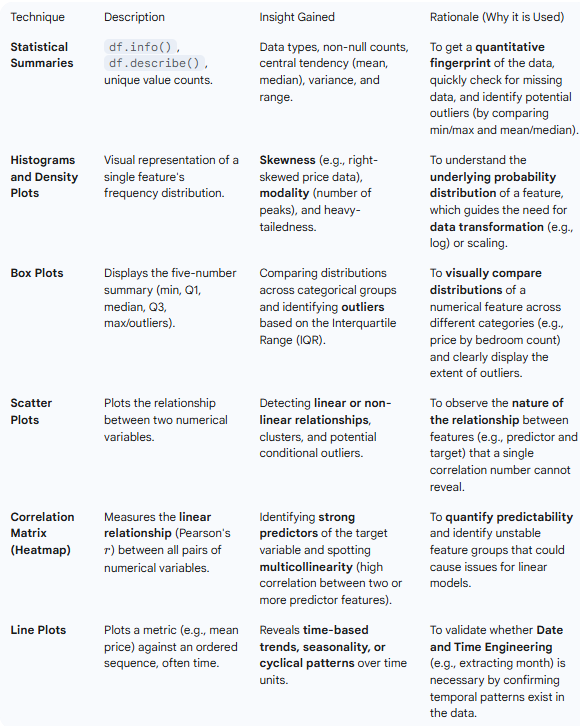



STEP 6: EXPLORATORY DATA ANALYSIS (EDA)
📊 6.1: Analyzing Feature Distributions
🔗 6.2: Analyzing Feature Correlations
🔍 6.3: Analyzing Feature Relationships
📅 6.4: Analyzing Temporal Patterns
✅ 6.5: Validating Engineered Features


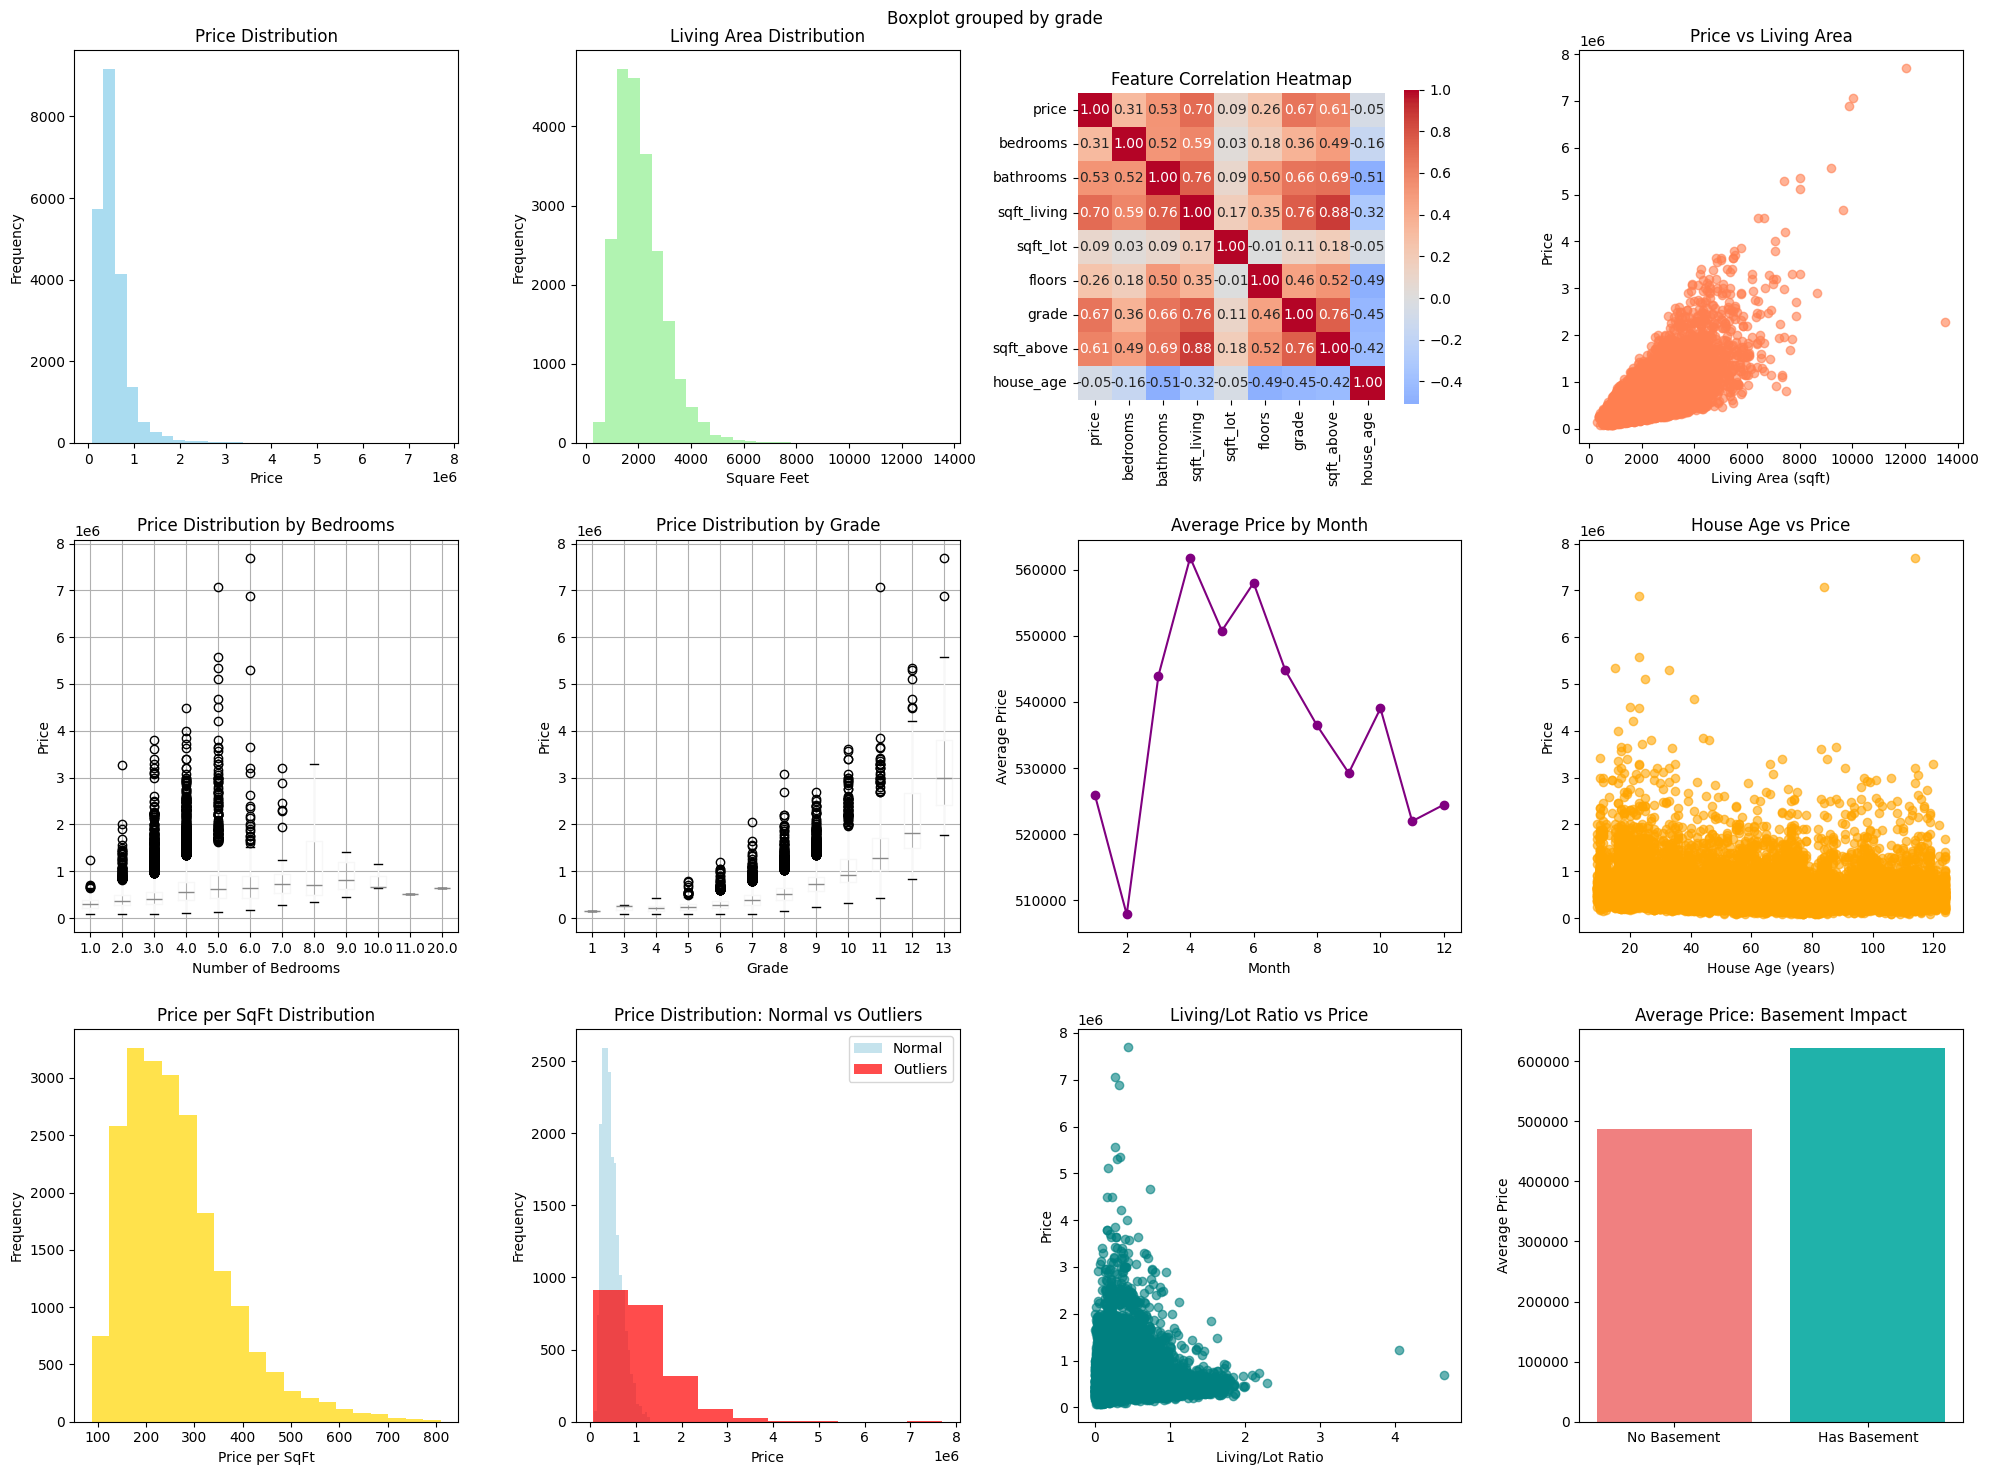


STEP 7: SUMMARY STATISTICS AND KEY INSIGHTS
📈 DATASET SUMMARY:
• Total records: 21613
• Total features after engineering: 60
• Price range: $75,000 - $7,700,000
• Average price: $540,088
• Average price per sqft: $264.16

🔍 KEY INSIGHTS:
• Strongest positive correlations with price:
  - sqft_living: 0.702
  - grade: 0.667
  - sqft_above: 0.606

• Engineered features impact:
  - Houses with basement: 8487 (39.3%)
  - Average house age: 53.0 years
  - Outliers detected: 2162 records

✅ DATA PREPARATION COMPLETE!
📊 Dataset is now ready for machine learning algorithms
🚀 Next steps: Model selection, training, and evaluation

STEP 8: SAVING PROCESSED DATASET

💾 Saving processed dataset to Google Drive...
✅ Processed dataset saved as: housing_data_processed_20250802_061000.csv
✅ Also saved as: housing_data_processed.csv (general version)

📋 Final Dataset Summary:
Shape: (21613, 60)
Memory usage: 8.62 MB

🎉 EXPERIMENT COMPLETED SUCCESSFULLY!


In [ ]:
# Set up the plotting environment
plt.figure(figsize=(20, 15))

# 6.1: Distribution Analysis
print("📊 6.1: Analyzing Feature Distributions")

# Price distribution
plt.subplot(3, 4, 1)
plt.hist(df_transformed['price'], bins=30, alpha=0.7, color='skyblue')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

# Living area distribution
plt.subplot(3, 4, 2)
plt.hist(df_transformed['sqft_living'], bins=30, alpha=0.7, color='lightgreen')
plt.title('Living Area Distribution')
plt.xlabel('Square Feet')
plt.ylabel('Frequency')

# 6.2: Correlation Analysis
print("🔗 6.2: Analyzing Feature Correlations")

# Select key numerical features for correlation
corr_features = ['price', 'bedrooms', 'bathrooms', 'sqft_living',
                'sqft_lot', 'floors', 'grade', 'sqft_above', 'house_age']
correlation_matrix = df_transformed[corr_features].corr()

plt.subplot(3, 4, 3)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap')

# 6.3: Relationship Analysis
print("🔍 6.3: Analyzing Feature Relationships")

# Price vs Living Area
plt.subplot(3, 4, 4)
plt.scatter(df_transformed['sqft_living'], df_transformed['price'], alpha=0.6, color='coral')
plt.title('Price vs Living Area')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price')

# Bedrooms vs Price
plt.subplot(3, 4, 5)
df_transformed.boxplot(column='price', by='bedrooms', ax=plt.gca())
plt.title('Price Distribution by Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')

# Grade vs Price
plt.subplot(3, 4, 6)
df_transformed.boxplot(column='price', by='grade', ax=plt.gca())
plt.title('Price Distribution by Grade')
plt.xlabel('Grade')
plt.ylabel('Price')

# 6.4: Temporal Analysis
print("📅 6.4: Analyzing Temporal Patterns")

# Price trends over months
plt.subplot(3, 4, 7)
monthly_avg = df_transformed.groupby('month')['price'].mean()
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', color='purple')
plt.title('Average Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Price')

# House age vs Price
plt.subplot(3, 4, 8)
plt.scatter(df_transformed['house_age'], df_transformed['price'], alpha=0.6, color='orange')
plt.title('House Age vs Price')
plt.xlabel('House Age (years)')
plt.ylabel('Price')

# 6.5: Feature Engineering Validation
print("✅ 6.5: Validating Engineered Features")

# Price per sqft distribution
plt.subplot(3, 4, 9)
plt.hist(df_transformed['price_per_sqft'], bins=20, alpha=0.7, color='gold')
plt.title('Price per SqFt Distribution')
plt.xlabel('Price per SqFt')
plt.ylabel('Frequency')

# Outlier analysis
plt.subplot(3, 4, 10)
outlier_prices = df_transformed[df_transformed['is_outlier'] == 1]['price']
normal_prices = df_transformed[df_transformed['is_outlier'] == 0]['price']
plt.hist(normal_prices, bins=20, alpha=0.7, label='Normal', color='lightblue')
plt.hist(outlier_prices, bins=10, alpha=0.7, label='Outliers', color='red')
plt.title('Price Distribution: Normal vs Outliers')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()

# Living area ratio analysis
plt.subplot(3, 4, 11)
plt.scatter(df_transformed['living_lot_ratio'], df_transformed['price'], alpha=0.6, color='teal')
plt.title('Living/Lot Ratio vs Price')
plt.xlabel('Living/Lot Ratio')
plt.ylabel('Price')

# Basement impact
plt.subplot(3, 4, 12)
basement_impact = df_transformed.groupby('has_basement')['price'].mean()
plt.bar(['No Basement', 'Has Basement'], basement_impact.values, color=['lightcoral', 'lightseagreen'])
plt.title('Average Price: Basement Impact')
plt.ylabel('Average Price')

plt.tight_layout()
plt.show()


# STEP 7: SUMMARY STATISTICS AND INSIGHTS

1. **Dataset Summary (Descriptive Statistics):**
  * It prints the final total number of records and features, confirming the impact of the cleaning and engineering steps.

  * It provides the range (min/max) and average for the target variable (price) and the engineered metric (price_per_sqft), establishing the scale and central tendency of the data.  

2. **Key Insights (Feature-Target Relationships):**

 * Strongest Correlations: It leverages the correlation matrix calculated in the EDA phase to display the top features that have the strongest positive linear relationship with price. This confirms which features will be most influential in the model.

 * Engineered Feature Impact: It reports the presence and average value of key engineered features:
    * The count and percentage of houses with a basement (has_basement).
    * The average house_age of the properties.
    * The total number of outliers detected.

In [ ]:
print("📈 DATASET SUMMARY:")
print(f"• Total records: {len(df_transformed)}")
print(f"• Total features after engineering: {df_transformed.shape[1]}")
print(f"• Price range: ${df_transformed['price'].min():,.0f} - ${df_transformed['price'].max():,.0f}")
print(f"• Average price: ${df_transformed['price'].mean():,.0f}")
print(f"• Average price per sqft: ${df_transformed['price_per_sqft'].mean():.2f}")

print("\n🔍 KEY INSIGHTS:")
# Correlation insights
price_correlations = df_transformed[corr_features].corr()['price'].sort_values(ascending=False)
print("• Strongest positive correlations with price:")
for feature, corr in price_correlations.head(4).items():
    if feature != 'price':
        print(f"  - {feature}: {corr:.3f}")

print("\n• Engineered features impact:")
print(f"  - Houses with basement: {df_transformed['has_basement'].sum()} ({df_transformed['has_basement'].mean()*100:.1f}%)")
print(f"  - Average house age: {df_transformed['house_age'].mean():.1f} years")
print(f"  - Outliers detected: {df_transformed['is_outlier'].sum()} records")

print("\n✅ DATA PREPARATION COMPLETE!")
print("📊 Dataset is now ready for machine learning algorithms")
print("🚀 Next steps: Model selection, training, and evaluation")


# STEP 8: SAVING PROCESSED DATASET

In [ ]:
# Save the processed dataset to Google Drive for future use
print("\n💾 Saving processed dataset to Google Drive...")
try:
    # Save with timestamp to avoid overwriting
    from datetime import datetime
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    processed_filename = f'/content/drive/MyDrive/housing_data_processed_{timestamp}.csv'
    df_transformed.to_csv(processed_filename, index=False)
    print(f"✅ Processed dataset saved as: housing_data_processed_{timestamp}.csv")

    # Also save a general version (will overwrite previous)
    general_filename = '/content/drive/MyDrive/housing_data_processed.csv'
    df_transformed.to_csv(general_filename, index=False)
    print(f"✅ Also saved as: housing_data_processed.csv (general version)")

except Exception as e:
    print(f"⚠️ Could not save to Google Drive: {str(e)}")
    print("💡 You can manually save using: df_transformed.to_csv('filename.csv', index=False)")

# Display final dataset info
print(f"\n📋 Final Dataset Summary:")
print(f"Shape: {df_transformed.shape}")
print(f"Memory usage: {df_transformed.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")